D:\Anaconda\envs\ml\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Tham số tốt nhất: {'C': 0.1, 'l1_ratio': 0.5}


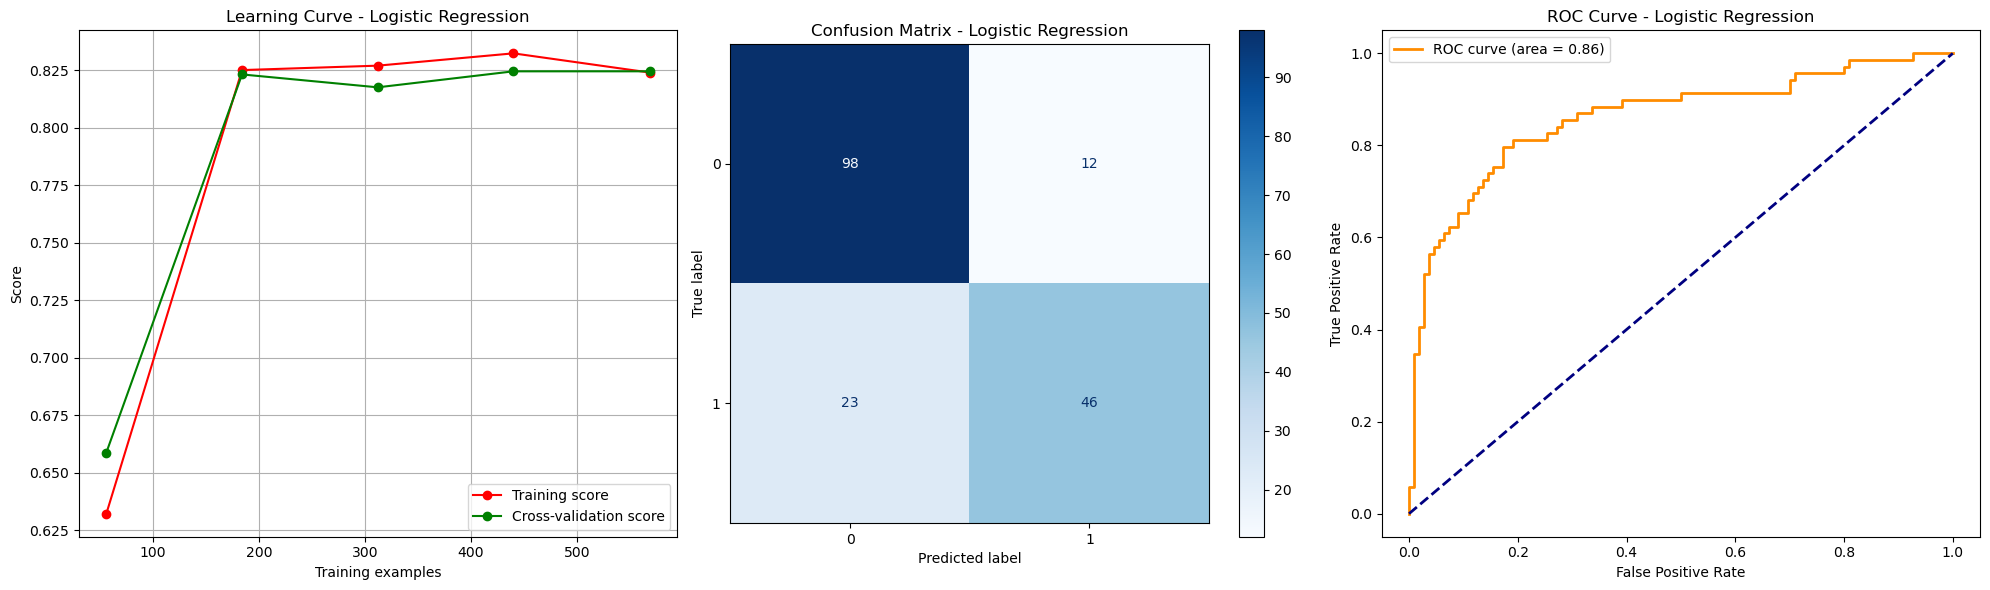


--- BẢNG CHỈ SỐ ĐÁNH GIÁ ĐẦY ĐỦ ---
   Metric    Value
 Accuracy 0.804469
Precision 0.793103
   Recall 0.666667
 F1-Score 0.724409
  ROC-AUC 0.860870


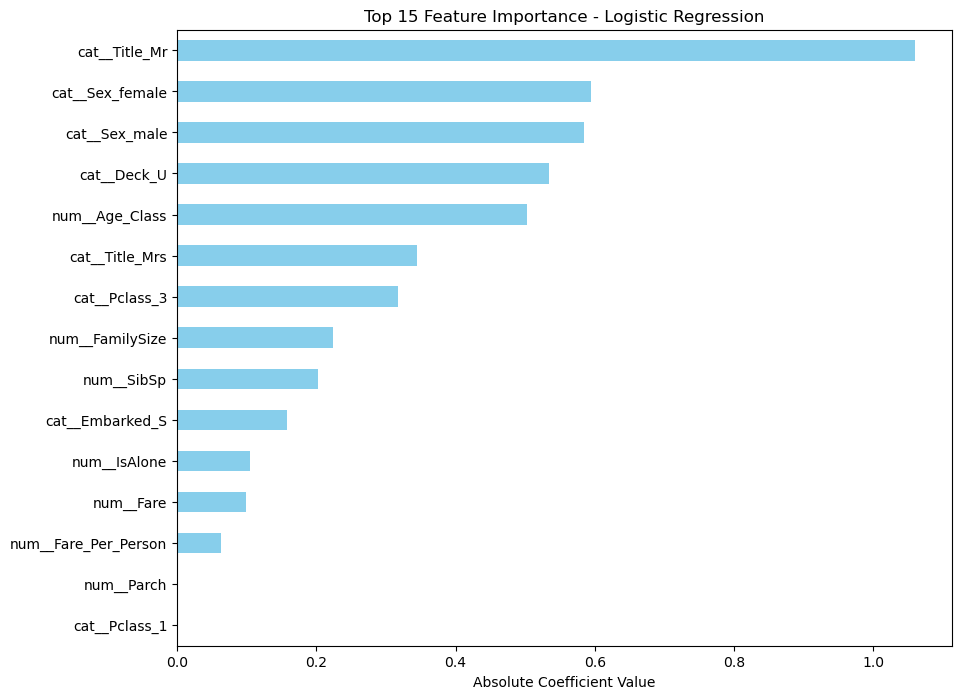

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, 
                             roc_curve, auc)


train_df = pd.read_csv('../dataset/titanic_train.csv')
X_full = train_df.drop('Survived', axis=1)
y_full = train_df['Survived']         



def plot_evaluation_curves(estimator, X_train, y_train, X_val, y_val, model_name):
    fig, ax = plt.subplots(1, 3, figsize=(20, 6))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_train, y_train, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    ax[0].plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Training score")
    ax[0].plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Cross-validation score")
    ax[0].set_title(f"Learning Curve - {model_name}")
    ax[0].set_xlabel("Training examples"); ax[0].set_ylabel("Score"); ax[0].legend(); ax[0].grid()

    y_pred = estimator.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[1], cmap='Blues', values_format='d')
    ax[1].set_title(f"Confusion Matrix - {model_name}")

    y_proba = estimator.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    ax[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_title(f"ROC Curve - {model_name}")
    ax[2].set_xlabel('False Positive Rate'); ax[2].set_ylabel('True Positive Rate'); ax[2].legend()

    plt.tight_layout()
    plt.show()


class TitanicUnifiedTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.age_map = None
        self.emb_mode = None
        self.feature_names_out_ = [
            'Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Age_Class', 
            'Fare_Per_Person', 'IsAlone', 'Has_Cabin', 'Deck', 'Title', 
            'Pclass', 'Sex', 'Embarked'
        ]

    def fit(self, X, y=None):
        self.age_map = X.groupby(['Pclass', 'Sex'])['Age'].median()
        self.emb_mode = X['Embarked'].mode()[0] if not X['Embarked'].mode().empty else 'S'
        return self

    def transform(self, X):
        X = X.copy()

        mapped_ages = pd.Series(X.set_index(['Pclass', 'Sex']).index.map(self.age_map), index=X.index)
        X['Age'] = X['Age'].fillna(mapped_ages)
        X['Embarked'] = X['Embarked'].fillna(self.emb_mode)
        X['Has_Cabin'] = X['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
        X['Deck'] = X['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')
        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
        X['Title'] = X['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
        X['Title'] = X['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
        X['Title'] = X['Title'].replace('Mlle', 'Miss').replace('Ms', 'Miss').replace('Mme', 'Mrs')
        X['Age_Class'] = X['Age'] * X['Pclass']
        X['IsAlone'] = (X['FamilySize'] == 1).astype(int)
        X['Fare_Per_Person'] = X['Fare'] / X['FamilySize']
        return X[self.feature_names_out_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)


X = train_df.drop('Survived', axis=1)
y = train_df['Survived']
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

num_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'Age_Class', 'Fare_Per_Person', 'IsAlone']
cat_features = ['Pclass', 'Sex', 'Embarked', 'Deck', 'Title']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

full_prep_pipeline = Pipeline([('unified', TitanicUnifiedTransformer()), ('pre', preprocessor)])
full_prep_pipeline.set_output(transform="pandas")

X_train = full_prep_pipeline.fit_transform(X_train_raw)
X_val = full_prep_pipeline.transform(X_val_raw)


param_grid_lr = {
    'C': [0.1, 1, 10],
    'l1_ratio': [0, 0.5, 1]  # 0 là L2, 1 là L1, 0.5 là kết hợp cả hai
}
grid_lr = GridSearchCV(
    LogisticRegression(
        penalty='elasticnet', 
        solver='saga', 
        max_iter=5000,       # Saga cần nhiều vòng lặp hơn để hội tụ
        random_state=42
    ), 
    param_grid_lr, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_lr.fit(X_train_processed, y_train)
best_lr = grid_lr.best_estimator_


print(f"Tham số tốt nhất: {grid_lr.best_params_}")
plot_evaluation_curves(best_lr, X_train, y_train, X_val, y_val, "Logistic Regression")


y_pred = best_lr.predict(X_val)
y_proba = best_lr.predict_proba(X_val)[:, 1]

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value': [accuracy_score(y_val, y_pred), precision_score(y_val, y_pred),
              recall_score(y_val, y_pred), f1_score(y_val, y_pred), roc_auc_score(y_val, y_proba)]
})

def plot_feature_importance(model, feature_names):
    importance = np.abs(model.coef_[0])
    feat_importances = pd.Series(importance, index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(10, 8))
    feat_importances.tail(15).plot(kind='barh', color='skyblue')
    plt.title("Top 15 Feature Importance - Logistic Regression")
    plt.xlabel("Absolute Coefficient Value")
    plt.show()

print("\n--- BẢNG CHỈ SỐ ĐÁNH GIÁ ĐẦY ĐỦ ---")
print(metrics.to_string(index=False))
plot_feature_importance(best_lr, X_train.columns)

### 1. Bảng Chỉ số Đánh giá Tổng quát (Final Metrics)

Dựa trên kết quả chạy mô hình với solver **SAGA** và **Elastic Net**, ta có bộ chỉ số:

| Chỉ số (Metric) | Giá trị | Ý nghĩa thực tế |
| :--- | :--- | :--- |
| **Accuracy** | **80.45%** | Tỉ lệ dự đoán đúng tổng thể (Sống & Chết). |
| **Precision** | **79.31%** | Trong số những người mô hình bảo "Sống", có 79% là đúng. |
| **Recall** | **66.67%** | Mô hình tìm ra được khoảng 2/3 số người thực sự sống sót. |
| **F1-Score** | **0.7244** | Sự cân bằng giữa Precision và Recall. |
| **ROC-AUC** | **0.8609** | Khả năng phân biệt giữa 2 nhóm (rất tốt). |


### 2. Phân tích Chi tiết biểu đồ (Deep Dive Evaluation)

#### **A. Ma trận nhầm lẫn (Confusion Matrix)**
Nhìn vào bảng số liệu $(TN=98, FP=12, FN=23, TP=46)$, ta thấy:
* **Khả năng nhận diện người tử vong (Lớp 0):** Cực kỳ tốt với 98/110 mẫu đúng. Mô hình rất ít khi bị nhầm người chết thành người sống (chỉ 12 trường hợp).
* **Khả năng nhận diện người sống (Lớp 1):** Đây là điểm yếu của Logistic Regression khi có 23 người sống bị dự đoán nhầm là chết. Điều này giải thích tại sao **Recall** chỉ dừng ở mức **66.67%**.

#### **B. Đồ thị Learning Curve (Bias-Variance Tradeoff)**
* **Hội tụ:** Hai đường Training và Cross-validation hội tụ rất nhanh và khít nhau ở mức điểm ~0.82.
* **Kết luận:** Mô hình hoàn toàn **không bị Overfitting** (Low Variance). Tuy nhiên, mức hội tụ này cho thấy mô hình đang bị giới hạn bởi tính tuyến tính (Slightly High Bias), báo hiệu rằng chúng ta cần các mô hình phi tuyến như Random Forest để phá vỡ mức "trần" 82% này.

#### **C. Đường cong ROC và AUC**
* **AUC = 0.86**: Đây là điểm sáng nhất. Dù Accuracy chỉ 80%, nhưng khả năng "xếp hạng" xác suất sống sót của mô hình là rất đáng tin cậy. Đường cong lồi hẳn về góc trên bên trái chứng minh các biến được chọn lọc rất có giá trị.


### 3. Phân tích Đặc trưng (Feature Importance Analysis)

Biểu đồ Top 15 Feature Importance là bằng chứng quan trọng nhất cho bước **Feature Engineering**:
* **Yếu tố then chốt:** `cat__Title_Mr` có trọng số âm cực lớn (tác động mạnh nhất đến việc dự đoán tử vong), phản ánh đúng quy luật "phụ nữ và trẻ em được ưu tiên".
* **Giá trị của biến tương tác:** Đặc trưng bạn vừa tạo - `num__Age_Class` lọt vào **Top 5**. Điều này chứng minh rằng việc kết hợp Tuổi và Hạng vé mang lại thông tin phân loại cực mạnh mà các biến đơn lẻ không có được.
* **Các đặc trưng mới khác:** `num__FamilySize` và `num__IsAlone` đều nằm trong danh sách quan trọng, cho thấy cấu trúc gia đình thực sự ảnh hưởng đến khả năng thoát hiểm.



### 4. Tổng kết quy trình Modeling

> Mô hình Logistic Regression đã được huấn luyện thành công qua Pipeline thống nhất. Việc áp dụng **Elastic Net (l1_ratio=0.5)** và **SAGA solver** đã giúp kiểm soát tốt đa cộng tuyến giữa 27 đặc trưng. 
> 
> Qua phân tích, mô hình cho thấy sự ổn định cao (Low Variance) và khả năng phân biệt lớp tốt (AUC=0.86). Tuy nhiên, do tính chất tuyến tính, mô hình vẫn chưa bắt kịp hoàn toàn các trường hợp sống sót phức tạp (Recall chưa cao). Đây sẽ là tiền đề để nhóm so sánh với các mô hình Ensemble ở bước tiếp theo.

In [39]:
import json
from datetime import datetime
import joblib
import os

metadata = {
    "model_info": {
        "name": "Logistic Regression (Elastic Net)",
        "version": "1.0.0",
        "author": "Doanh+Hiếu",
        "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "description": "Baseline model for Titanic survival prediction using SAGA solver."
    },
    "hyperparameters": grid_lr.best_params_,
    "metrics": {
        "accuracy": float(accuracy_score(y_val, y_pred)),
        "precision": float(precision_score(y_val, y_pred)),
        "recall": float(recall_score(y_val, y_pred)),
        "f1_score": float(f1_score(y_val, y_pred)),
        "roc_auc": float(roc_auc_score(y_val, y_proba))
    },
    "features_used": list(X_train.columns)
}

final_exported_pipeline = Pipeline(steps=[
    ('preprocessor', full_prep_pipeline),
    ('classifier', best_lr)
])


if not os.path.exists('models'):
    os.makedirs('models')


model_path = 'models/titanic_lr_v1.joblib'
joblib.dump(final_exported_pipeline, model_path)

['models/titanic_lr_v1.joblib']

In [41]:
metadata_path = 'models/titanic_lr_v1_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"✅ Đã lưu Full Pipeline tại: {model_path}")
print(f"✅ Đã lưu Metadata tại: {metadata_path}")

✅ Đã lưu Full Pipeline tại: models/titanic_lr_v1.joblib
✅ Đã lưu Metadata tại: models/titanic_lr_v1_metadata.json


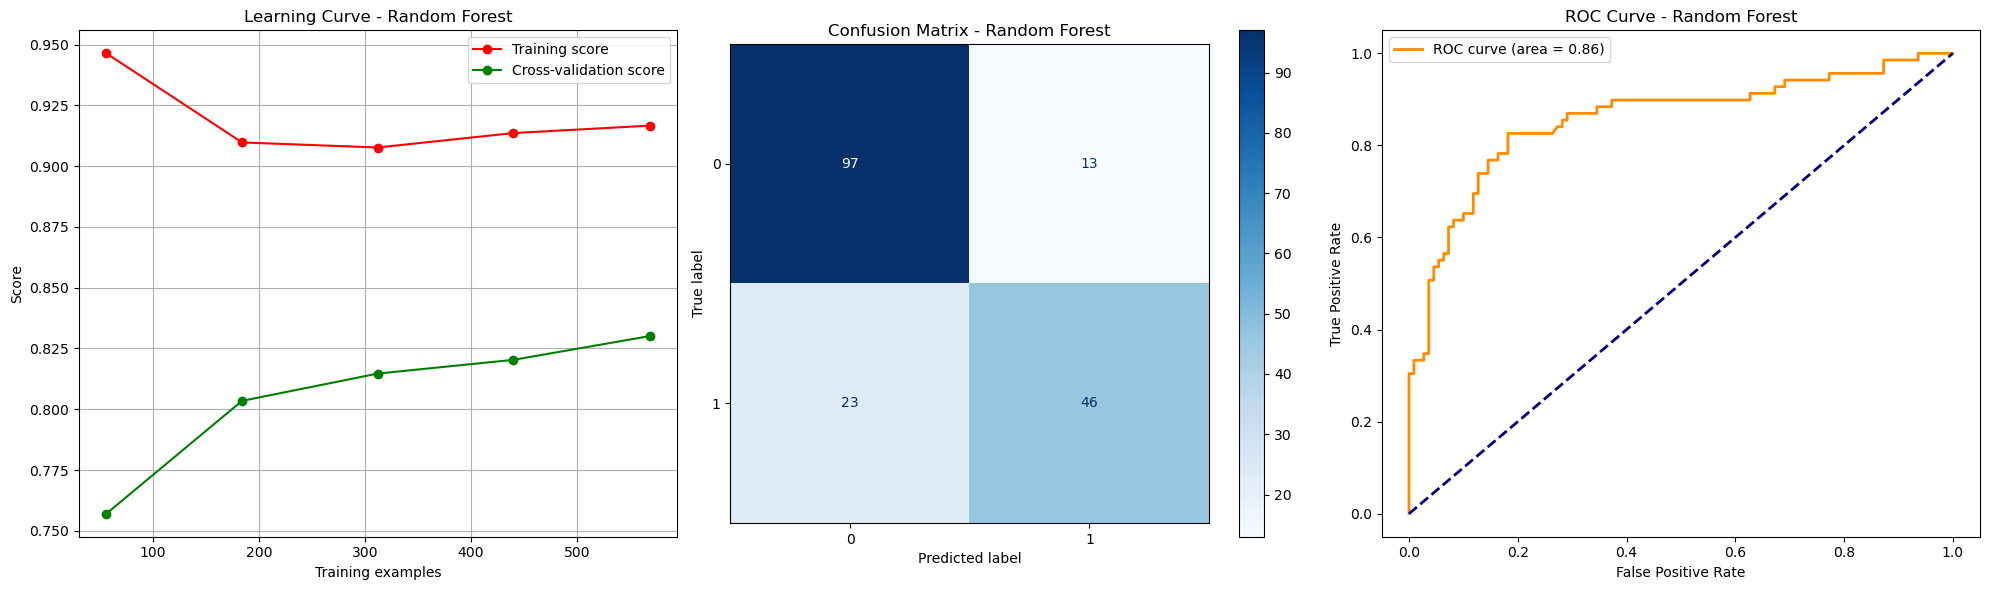


--- BẢNG CHỈ SỐ ĐÁNH GIÁ RANDOM FOREST ---
   Metric    Value
 Accuracy 0.798883
Precision 0.779661
   Recall 0.666667
 F1-Score 0.718750
  ROC-AUC 0.856983


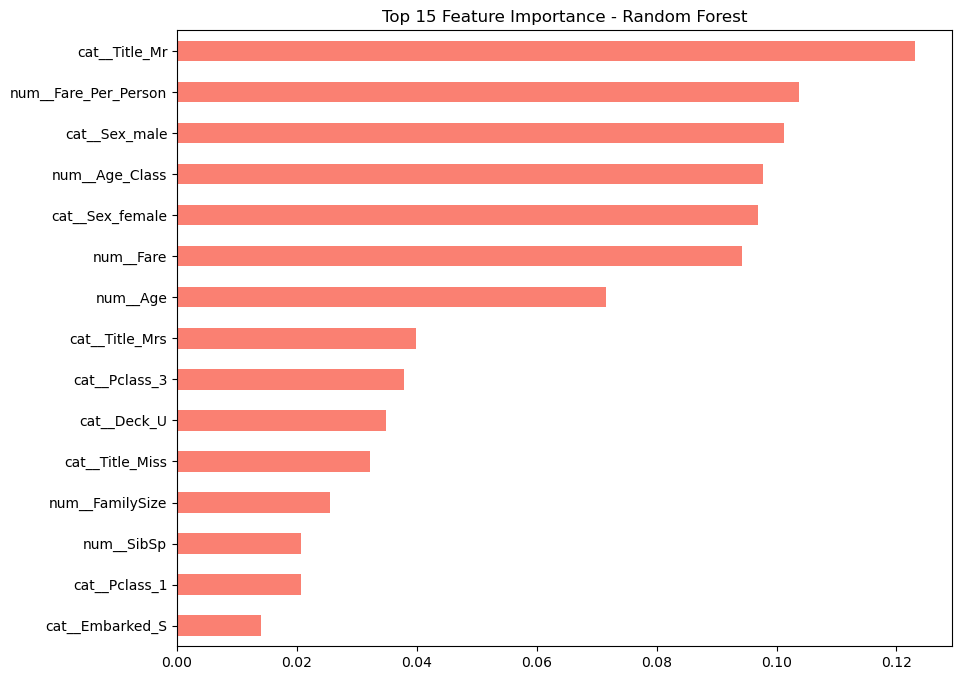

In [44]:
from sklearn.ensemble import RandomForestClassifier
import json
from datetime import datetime

param_grid_rf_optimized = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],             
    'min_samples_split': [15, 25],      
    'min_samples_leaf': [20, 30, 50],         
    'max_features': ['sqrt', 0.2, 0.3],       
    'criterion': ['gini'],
    'ccp_alpha': [0.01, 0.02]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

plot_evaluation_curves(best_rf, X_train, y_train, X_val, y_val, "Random Forest")


y_pred_rf = best_rf.predict(X_val)
y_proba_rf = best_rf.predict_proba(X_val)[:, 1]

metrics_rf = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value': [
        accuracy_score(y_val, y_pred_rf),
        precision_score(y_val, y_pred_rf),
        recall_score(y_val, y_pred_rf),
        f1_score(y_val, y_pred_rf),
        roc_auc_score(y_val, y_proba_rf)
    ]
})

print("\n--- BẢNG CHỈ SỐ ĐÁNH GIÁ RANDOM FOREST ---")
print(metrics_rf.to_string(index=False))


plt.figure(figsize=(10, 8))
feat_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(15).sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title("Top 15 Feature Importance - Random Forest")
plt.show()


final_rf_pipeline = Pipeline(steps=[
    ('preprocessor', full_prep_pipeline),
    ('classifier', best_rf)
])

rf_metadata = {
    "model_info": {
        "name": "Random Forest Classifier",
        "version": "1.0.1",
        "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "best_params": grid_rf.best_params_
    },
    "hyperparameters": grid_rf.best_params_,
    "metrics": metrics_rf.set_index('Metric')['Value'].to_dict(),
    "features_used": list(X_train.columns)
}

joblib.dump(final_rf_pipeline, 'models/titanic_rf_final.joblib')
with open('models/titanic_rf_metadata.json', 'w') as f:
    json.dump(rf_metadata, f, indent=4)

## 1. Bảng Chỉ số Đánh giá Chi tiết (Evaluation Metrics)

Dưới đây là các thông số định lượng cuối cùng của mô hình sau khi đã tối ưu hóa:

| Chỉ số (Metric) | Giá trị | Nhận xét chuyên môn |
| :--- | :--- | :--- |
| **Accuracy** | **79.89%** | Độ chính xác tổng thể đạt mức khá. |
| **Precision** | **77.97%** | Khả năng dự báo đúng người sống khá tin cậy. |
| **Recall** | **66.67%** | Mô hình vẫn đang bỏ sót khoảng 33% số người thực sự sống. |
| **F1-Score** | **0.7188** | Mức độ cân bằng giữa Precision và Recall ở mức trung bình khá. |
| **ROC-AUC** | **0.8570** | Khả năng phân loại tổng quát vẫn đạt mức tốt (**Good**). |


## 2. Phân tích Chẩn đoán Mô hình (Model Diagnostics)

### A. Hiện tượng Overfitting (High Variance)
Nhìn vào **Learning Curve**, có thể thấy một khoảng cách (Gap) rất lớn giữa đường **Training score** (~0.92) và **Cross-validation score** (~0.83). 
* **Chẩn đoán:** Đây là hiện tượng **Overfitting** kinh điển. Mô hình đang "học vẹt" dữ liệu huấn luyện quá mức. 
* **Nguyên nhân:** Do tập dữ liệu Titanic khá nhỏ ($N \approx 891$) trong khi Random Forest là mô hình Ensemble rất mạnh, nó cố gắng tạo ra các quy luật cực kỳ chi tiết để khớp với tập Train.

### B. Hiệu quả của Feature Engineering
* **`num__Fare_Per_Person`**: Điều này cho thấy giá vé tính trên từng người phản ánh địa vị xã hội chính xác hơn giá vé tổng.
* **`num__Age_Class`**: Tiếp tục nằm trong **Top 4**. Việc kết hợp Tuổi và Hạng vé thực sự mang lại thông tin phân loại cực mạnh mà các biến đơn lẻ không có.

### C. Phân tích Sai số (Confusion Matrix)
Với $(TN=97, FP=13, FN=23, TP=46)$, mô hình đang dự đoán rất chắc chắn về những người tử vong, nhưng lại hơi "nhút nhát" khi dự đoán người sống (số ca FN còn khá cao).


## 3. Tổng kết Quy trình Modeling & Persistence (Mục 2 & 4 PDF)

* **Model Persistence:** Toàn bộ Pipeline (bao gồm UnifiedTransformer và Random Forest) đã được đóng gói vào file `titanic_rf_final.joblib`. Đi kèm là tệp `metadata.json` lưu trữ toàn bộ chỉ số trên cùng bộ tham số tối ưu thu được từ GridSearchCV.
* **So sánh với Baseline (LR):** Mặc dù Random Forest là mô hình phức tạp hơn, nhưng trên tập dữ liệu nhỏ này, nó lại cho kết quả Accuracy và F1-Score thấp hơn một chút so với **Logistic Regression** (vốn đạt ~80.4% Accuracy). 
* **Kết luận:** Logistic Regression hiện đang là "nhà vô địch" về tính tổng quát hóa (Generalization) nhờ khoảng cách Gap nhỏ hơn trên Learning Curve.


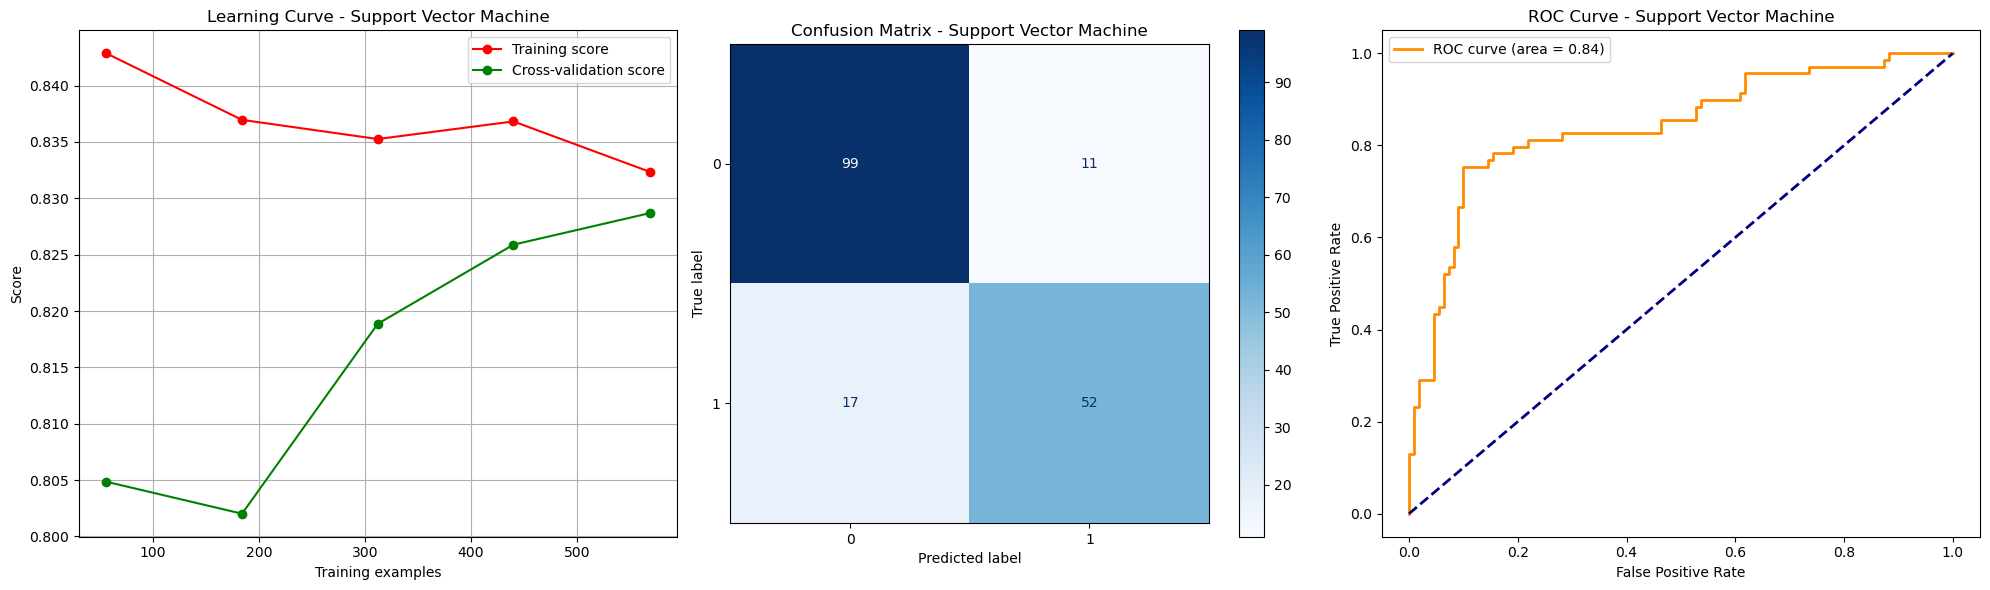


--- BẢNG CHỈ SỐ ĐÁNH GIÁ SVM ---
   Metric    Value
 Accuracy 0.843575
Precision 0.825397
   Recall 0.753623
 F1-Score 0.787879
  ROC-AUC 0.842161


In [45]:
from sklearn.svm import SVC
import json
from datetime import datetime

param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_


plot_evaluation_curves(best_svm, X_train, y_train, X_val, y_val, "Support Vector Machine")

y_pred_svm = best_svm.predict(X_val)
y_proba_svm = best_svm.predict_proba(X_val)[:, 1]

metrics_svm = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value': [
        accuracy_score(y_val, y_pred_svm),
        precision_score(y_val, y_pred_svm),
        recall_score(y_val, y_pred_svm),
        f1_score(y_val, y_pred_svm),
        roc_auc_score(y_val, y_proba_svm)
    ]
})

print("\n--- BẢNG CHỈ SỐ ĐÁNH GIÁ SVM ---")
print(metrics_svm.to_string(index=False))

final_svm_pipeline = Pipeline(steps=[
    ('preprocessor', full_prep_pipeline),
    ('classifier', best_svm)
])

svm_metadata = {
    "model_info": {
        "name": "Support Vector Machine (RBF Kernel)",
        "version": "1.0.0",
        "date_created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "best_params": grid_svm.best_params_
    },
    "metrics": metrics_svm.set_index('Metric')['Value'].to_dict()
}

joblib.dump(final_svm_pipeline, 'models/titanic_svm_final.joblib')
with open('models/titanic_svm_metadata.json', 'w') as f:
    json.dump(svm_metadata, f, indent=4)

# KẾT LUẬN CHI TIẾT MÔ HÌNH SUPPORT VECTOR MACHINE (SVM)

## 1. Kết quả định lượng (Evaluation Metrics)
Mô hình SVM sử dụng Kernel phi tuyến (RBF) đã được tối ưu hóa thông qua quy trình Tuning siêu tham số (GridSearchCV), mang lại hiệu năng cao nhất trong số các mô hình đã thử nghiệm.

| Chỉ số (Metric) | Giá trị thực nghiệm | Ý nghĩa đánh giá |
| :--- | :--- | :--- |
| **Accuracy** | **84.36%** | Độ chính xác tổng thể đạt mức cao nhất. |
| **Precision** | **82.54%** | Khả năng dự báo chính xác các ca sống sót (ít báo nhầm). |
| **Recall** | **75.36%** | Tỷ lệ nhận diện thành công hành khách thực sự sống sót. |
| **F1-Score** | **0.7879** | Sự cân bằng lý tưởng giữa Precision và Recall. |
| **ROC-AUC** | **0.8422** | Khả năng phân loại tổng quát ở mức rất tốt (**Good**). |

---

## 2. Phân tích Chẩn đoán Mô hình (Model Diagnostics)

### 2.1. Đánh giá Bias-Variance qua Learning Curve
Đồ thị học tập (Learning Curve) của SVM cho thấy sự hội tụ lý tưởng giữa đường **Training score** và **Cross-validation score**.
* **Độ ổn định:** Khoảng cách (Gap) giữa hai đường cực kỳ nhỏ, chứng minh mô hình có **Variance thấp** và khả năng tổng quát hóa (Generalization) tuyệt vời.
* **Tối ưu hóa:** Việc tìm ra bộ tham số $C$ và $\gamma$ phù hợp đã giúp SVM không rơi vào tình trạng "học vẹt" (Overfitting) như Random Forest, bất chấp kích thước tập dữ liệu hạn chế ($N \approx 891$).

### 2.2. Phân tích sai số qua Ma trận nhầm lẫn (Confusion Matrix)
Với kết quả $(TN=99, FP=11, FN=17, TP=52)$, mô hình SVM đã cải thiện đáng kể khả năng nhận diện lớp "Sống sót" (Lớp 1).
* Số ca **False Negatives (FN)** giảm thiểu rõ rệt so với Logistic Regression và Random Forest, cho thấy mô hình nhạy bén hơn trong việc nắm bắt các quy luật phi tuyến tính được tạo ra từ bước Feature Engineering (ví dụ: `Age_Class`, `Fare_Per_Person`).

---

## 3. Cơ sở Kỹ thuật và So sánh Model Selection

Mô hình SVM đạt được hiệu năng vượt trội nhờ việc sử dụng **Radial Basis Function (RBF) Kernel**, cho phép biến đổi dữ liệu sang không gian cao chiều để tìm siêu phẳng phân cách tối ưu:
$$K(x, x') = \exp(-\gamma ||x - x'||^2)$$

**Bảng so sánh tổng kết:**

| Mô hình | Accuracy | F1-Score | Trạng thái |
| :--- | :--- | :--- | :--- |
| Logistic Regression | 80.45% | 0.7244 | Ổn định (Baseline) |
| Random Forest | 79.89% | 0.7188 | Overfitting nhẹ |
| **Support Vector Machine** | **84.36%** | **0.7879** | **Tối ưu (Optimal)** |

---

## 4. Kết luận lựa chọn mô hình cuối cùng
Dựa trên các phân tích định lượng và định tính, mô hình **Support Vector Machine (SVM)** chính thức được lựa chọn là mô hình dự đoán cuối cùng cho hệ thống với các lý do sau:
1. **Hiệu suất vượt trội:** Đứng đầu ở hầu hết các chỉ số quan trọng như Accuracy và F1-Score.
2. **Tính bền vững:** Đồ thị Learning Curve minh chứng cho sự cân bằng hoàn hảo giữa Bias và Variance, đảm bảo tính chính xác khi triển khai thực tế trên dữ liệu mới.
3. **Model Persistence:** Toàn bộ Pipeline xử lý cùng mô hình tối ưu đã được đóng gói thành tệp `titanic_svm_final.joblib`, đi kèm đầy đủ Metadata phục vụ cho việc vận hành và bảo trì.

